### SISTEMA DE COMPRESSÃO DE IMAGENS POR DECOMPOSIÇÃO EM VALORES SINGULARES ###


##### Imports ####

In [2]:
import numpy as np 
import pandas as pd
from PIL import Image
import io
import plotly.express as px
import matplotlib.pyplot as plt

#### Carrega e faz o plot da imagem ####

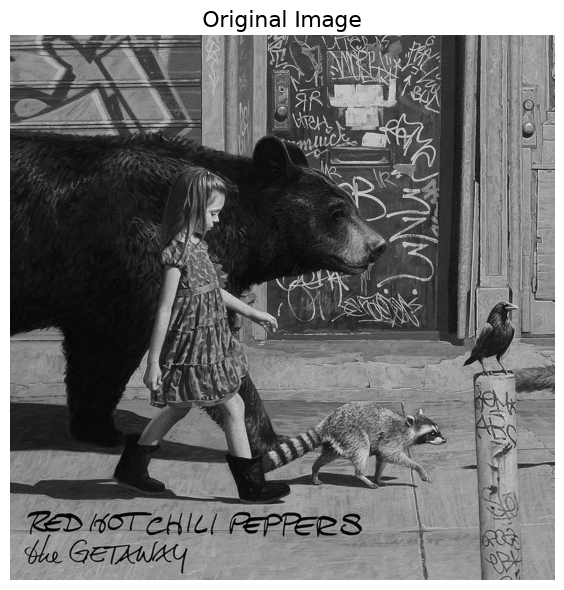

In [3]:
img = np.array(Image.open("the_getaway.jpg"))
X = np.mean(img, axis=-1)

fig, ax = plt.subplots(figsize=(6, 6))

ax.imshow(X, cmap="gray")
ax.set_title("Original Image", fontsize=16)
ax.axis("off")

plt.tight_layout()

#### Calcula o SVD pela função np.linalg.svd e realiza o plot da imagem para níveis de truncamento de 5, 20, 200, 700, 900 valores singulares ####

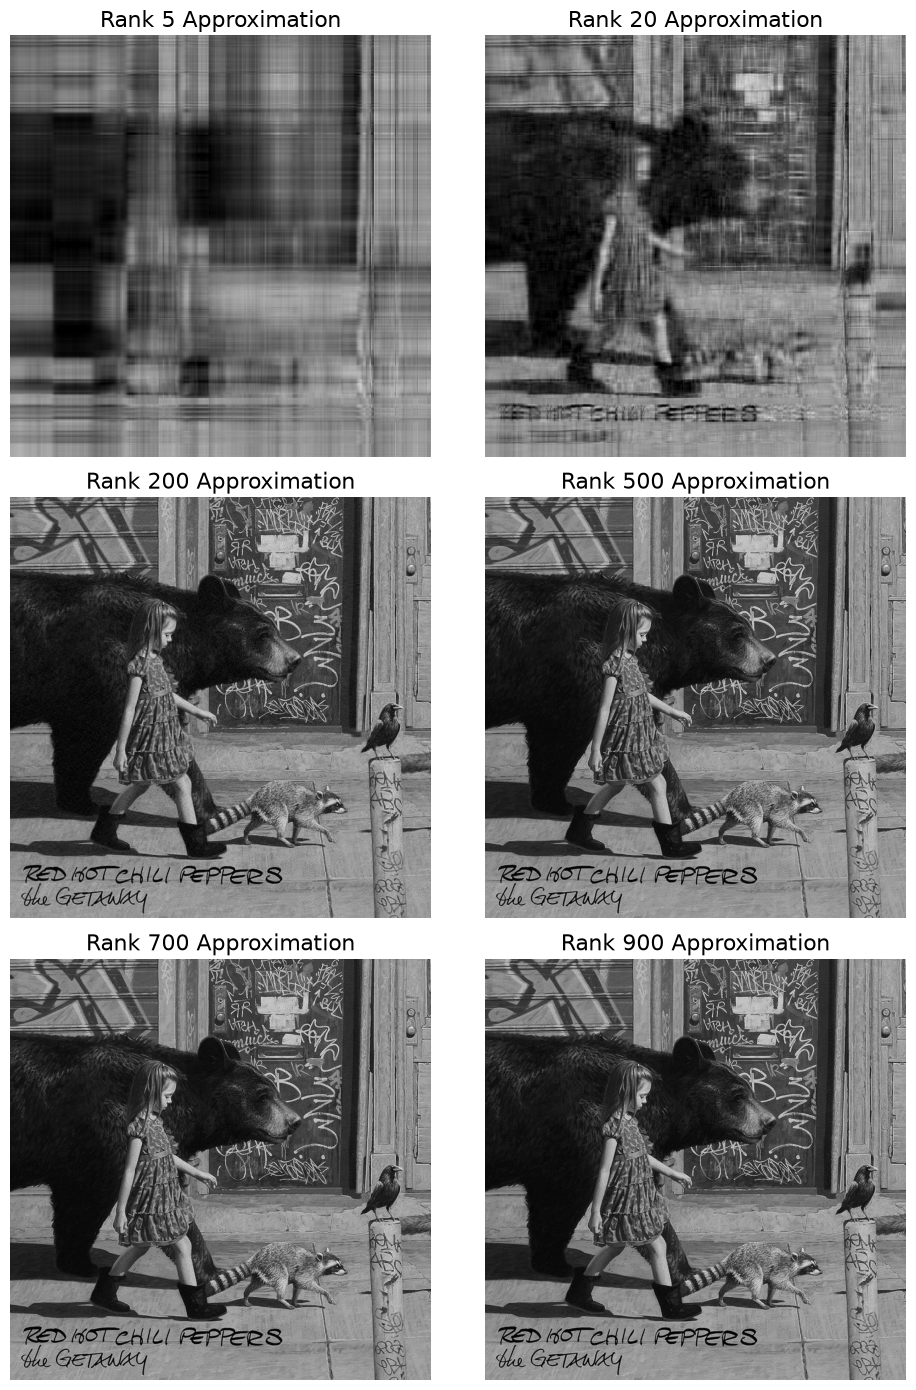

In [4]:
U, S, Vt = np.linalg.svd(X, full_matrices=False)

ranks = [5, 20, 200, 500, 700, 900]

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(10, 14))
for ax, k in zip(axes.ravel(), ranks):
    
    ax.imshow(U[:, :k] @ np.diag(S[:k]) @ Vt[:k, :], cmap="gray", vmin=0, vmax=255)
    ax.set_title(f"Rank {k} Approximation", fontsize=16)
    ax.axis("off")

plt.tight_layout()


### Cálculo do MSE (Mean Squared Error), PSNR (Peak Signal-to-Noise Ratio) e energia preservada a cada valor singular

#####   MSE mede a diferênça média entre os pixels da imagem original e a imagem reconstruída.
#####       $\mathrm{MSE} = \frac{1}{mn}  \sum_{m,n} \left( X_{ij} - \hat{X}_{ij} \right)^2$


#####   PSNR é a Razão Sinal Ruído de Pico e mede a qualidade da imagem reconstruído em relação a original em dB
#####       $\mathrm{PSNR} = 10 \cdot \log_{10} \left( \frac{MAX^2}{\mathrm{MSE}} \right)$
#####       sendo MAX o valor máximo do pixer (225 para uint8)

In [5]:
mse_values = []
psnr = []
energy_retained = []

ranks = np.arange(1, min(X.shape) + 1)

for r in ranks:
    X_approx = U[:, :r] @ np.diag(S[:r]) @ Vt[:r, :]
    mse = np.mean((X - X_approx) ** 2)
    mse_values.append(mse)

    psnr.append(10*np.log10(np.max(X)**2 / mse))

    energy_retained.append(np.sum(S[:r]**2) / np.sum(S**2))


#### Plot do MSE e PSNR

In [6]:
fig_mse = px.line(
    x=ranks,
    y=mse_values,
    labels={"x": "Rank", "y": "MSE"},
    title="Mean Squared Error (MSE) vs Rank"
)

fig_mse.update_traces(line=dict(width=4, color="red"))

fig_mse.update_layout(
    font=dict(
        size=16,
        color="black",      
    )
)

fig_psnr = px.line(
    x=ranks,
    y=psnr,
    labels={"x": "Rank", "y": "PSNR (dB)"},
    title="Peak Signal-to-Noise Ratio (PSNR) vs Rank",
    
)

fig_psnr.update_traces(line=dict(width=4, color="blue"))

fig_psnr.update_layout(
    font=dict(
        size=16,
        color="black"
    )
)       

fig_mse.show()
fig_psnr.show()


#### Plot dos valores singulares e da energia acumulada 

In [7]:
fig_singular_values = px.line(
    x=ranks,
    y=S[:len(ranks)],
    labels={"x": "Rank", "y": "Singular Values"},
    title="Singular Values vs Rank"
)

fig_singular_values.update_traces(line=dict(width=4, color="green"))

fig_singular_values.update_yaxes(type='log')
fig_singular_values.update_layout(
    font=dict(
        size=16,
        color="black",
    )
)

fig_energy_retained = px.line(
    x=ranks,
    y=energy_retained,
    labels={"x": "Rank", "y": "Energy Retained"},
    title="Energy Retained vs Rank"
)

fig_energy_retained.update_traces(line=dict(width=4, color="magenta"))

fig_energy_retained.update_layout(
    font=dict(
        size=16,
        color="black",
    ),
)

fig_singular_values.show()
fig_energy_retained.show()

#### Taxa de compressão 

##### Compression Rate (CR) = $\frac{m \cdot n}{r \cdot (m+n+1)}$

In [8]:
m, n = X.shape
print(f"Image dimensions: {m} x {n}")

compression_ratio = []

for r in ranks:
    cr = (m * n) / (r * (m + n + 1))
    compression_ratio.append(cr)

fig_compression_ratio = px.line(
    x=ranks,
    y=compression_ratio,
    labels={"x": "Rank", "y": "Compression Ratio"},
    title="Compression Ratio vs Rank"
)

fig_compression_ratio.update_traces(line=dict(width=4, color="purple"))

fig_compression_ratio.update_layout(
    font=dict(
        size=16,
        color="black",
    )
)

fig_compression_ratio.show()

Image dimensions: 1000 x 1000


#### Comparação entre taxa de compressão e armazenamento para diferentes níveis de truncamento dos valores singulares

##### Compression Rate (CR) = $\frac{m \cdot n}{r \cdot (m+n+1)}$

##### Storage = $100 \cdot \frac{r \cdot (m+n+1)}{m \cdot n}$

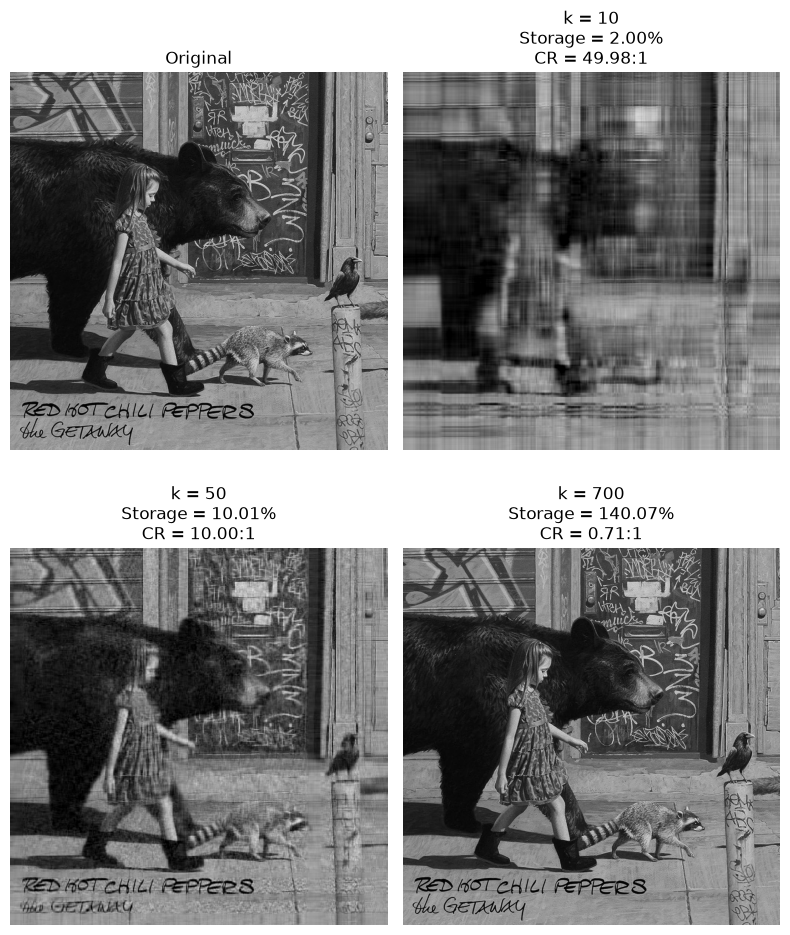

In [9]:
ranks_st = [None, 10, 50, 700]

fig, axes = plt.subplots(2, 2, figsize=(8, 10))

for ax, k in zip(axes.ravel(), ranks_st):

    if k is None:
        img = X
        title = "Original"
    else:
        img = U[:, :k] @ np.diag(S[:k]) @ Vt[:k, :]
        storage = 100 * k * (m + n + 1) / (m * n)
        cr = (m * n) / (k * (m + n + 1))

        title = (
            f"k = {k}\n"
            f"Storage = {storage:.2f}%\n"
            f"CR = {cr:.2f}:1"
        )

    ax.imshow(np.clip(img, 0, 255), cmap="gray", vmin=0, vmax=255)
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()

### Comparação com JPEG 
#### Para a comparação, buscou-se comprimir a imagem a partir de ambos os métodos com a mesma taxa de compressão (CR)

#### Declaração de funções

In [10]:
def svd_reconstruct(U, S, Vt, k):
    return U[:, :k] @ np.diag(S[:k]) @ Vt[:k, :]

def svd_size_bytes(m, n, k):
    return 8 * k * (m + n + 1)

def jpeg_compress(image, quality):
    buffer = io.BytesIO()
    img_pil = Image.fromarray(image.astype(np.uint8))
    img_pil.save(buffer, format="JPEG", quality=quality)
    return buffer.getvalue(), np.array(Image.open(io.BytesIO(buffer.getvalue())))

def mse(X, X_hat):
    return np.mean((X - X_hat) ** 2)

def psnr(X, X_hat):
    max_val = 255
    m = mse(X, X_hat)
    return 10 * np.log10((max_val ** 2) / m)

### Comparação das métricas MSE e PSNR para o mesmo nível de compressão

##### Image.fromarray não tem CR de input, ele recebe qualidade do sinal e posteriormente é calculada a CR. A partir da CR obtida, calcula-se o truncamento do método da SVD com uma CR que mais se aproxima do JPEG

In [11]:
m, n = X.shape
original_size = m * n 

U, S, Vt = np.linalg.svd(X, full_matrices=False)

qualities = [90, 60, 30, 5]

jpeg_results = []
jpeg_imgs = []

for q in qualities:

    buffer = io.BytesIO()
    Image.fromarray(X.astype(np.uint8)).save(
        buffer,
        format="JPEG",
        quality=q
    )

    jpeg_bytes = buffer.getvalue()
    jpeg_size = len(jpeg_bytes)

    jpeg_img = np.array(Image.open(io.BytesIO(jpeg_bytes)))
    jpeg_imgs.append(jpeg_img)

    jpeg_results.append({
        "quality": q,
        "size": jpeg_size,
        "cr": original_size / jpeg_size,
        "mse": mse(X, jpeg_img),
        "psnr": psnr(X, jpeg_img)
    })

svd_results = []
svd_imgs = []

for j in jpeg_results:

    target_size = j["size"]

    k = np.ceil(target_size / (8 * (m + n + 1))).astype(int)
    k = max(1, min(k, len(S)))

    X_svd = svd_reconstruct(U, S, Vt, k)
    svd_imgs.append(X_svd)

    svd_size = svd_size_bytes(m, n, k)

    svd_results.append({
        "quality": j["quality"],
        "k": k,
        "size": svd_size,
        "cr": original_size / svd_size,
        "mse": mse(X, X_svd),
        "psnr": psnr(X, X_svd)
    })

df_jpeg = pd.DataFrame(jpeg_results)
df_svd = pd.DataFrame(svd_results)
df = pd.merge(df_jpeg, df_svd, on="quality", suffixes=("_jpeg", "_svd"))

display(df)

,quality,size_jpeg,cr_jpeg,mse_jpeg,psnr_jpeg,k,size_svd,cr_svd,mse_svd,psnr_svd
0,90,280191,3.568994,1.253401,47.149905,18,288144,3.470487,637.393135,20.086730
1,60,158840,6.295643,22.759965,34.559088,10,160080,6.246877,814.263724,19.023153
2,30,100355,9.964626,57.471359,30.536289,7,112056,8.924109,944.573453,18.378446
3,5,26752,37.380383,255.520113,24.056553,2,32016,31.234383,1570.020011,16.171752


#### Plot das imagens para a mesma taxa de compressõa para JPEG e SVD 

##### Note que, claramente o JPEG tem uma qualidade muito superior ao SVD, justificando o sua popularidade e porque o SVD não é utilizado nessa aplicação em espefíco

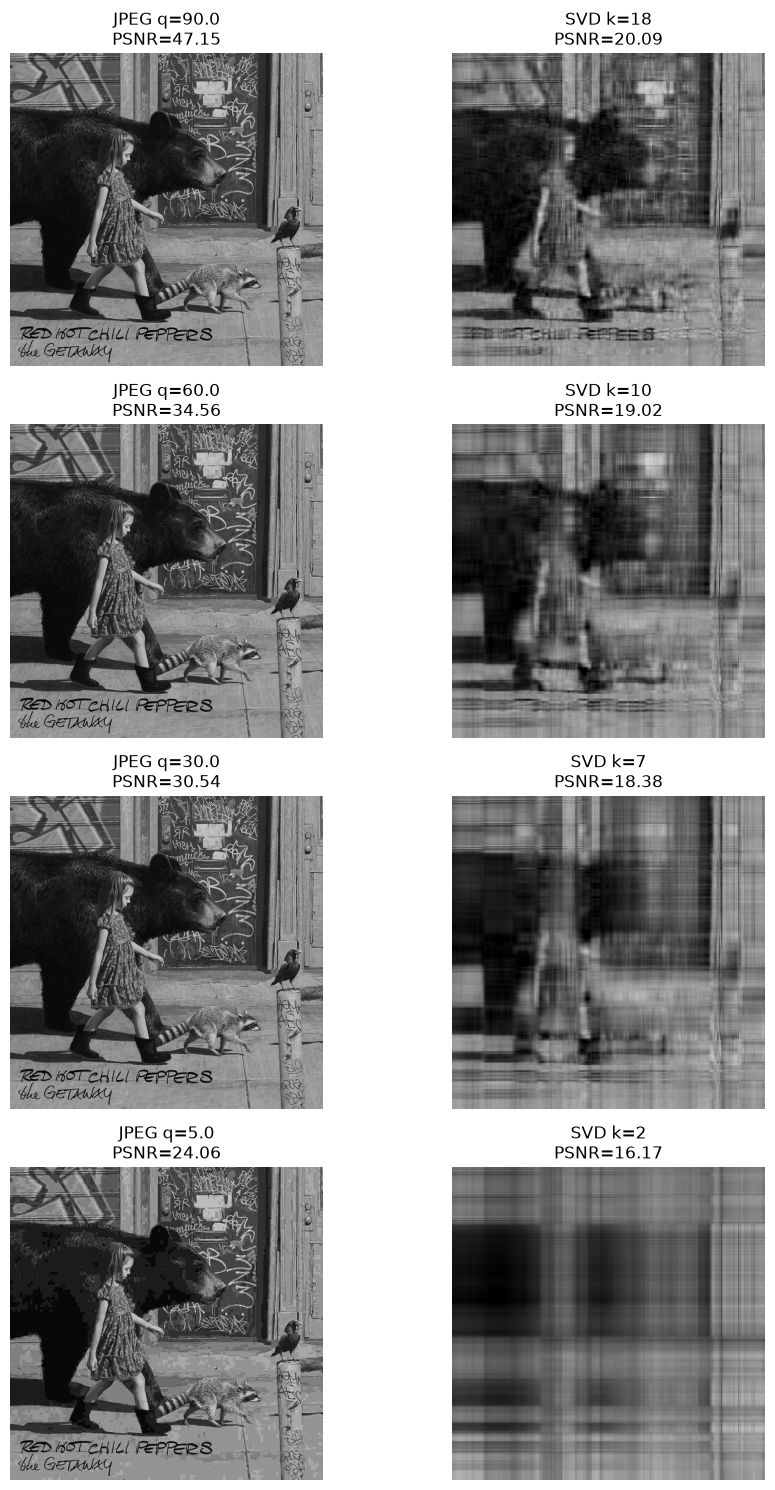

In [12]:
fig, axes = plt.subplots(4, 2, figsize=(10, 15))

for i, row in df.iterrows():

    axes[i, 0].imshow(jpeg_imgs[i], cmap="gray", vmin=0, vmax=255)
    axes[i, 0].set_title(f"JPEG q={row['quality']}\nPSNR={row['psnr_jpeg']:.2f}")
    axes[i, 0].axis("off")

    k = int(row["k"])

    axes[i, 1].imshow(np.clip(svd_imgs[i], 0, 255), cmap="gray", vmin=0, vmax=255)
    axes[i, 1].set_title(f"SVD k={k}\nPSNR={row['psnr_svd']:.2f}")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()